# Proyecto 7 - Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [51]:
# Importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


### Cargar Dataset

In [52]:
# Cargar el dataset y explorar datos
df = pd.read_csv('/datasets/novaretail_comportamiento_clientes_2024.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [53]:
# mostrar las primeras 5 filas
df.head()

  id_cliente  edad  nivel_ingreso  visitas_mes  compras_mes  \
0  CL-100000  44.0       28565.77            9            1   
1  CL-100001  36.0       29673.44           11            3   
2  CL-100002  46.0       30642.95            9            0   
3  CL-100003  56.0       39468.61            8            0   
4  CL-100004  35.0       22527.83            9            2   

   gasto_publicidad_dirigida  satisfaccion  miembro_premium  abandono  \
0                      31.36           3.9                0         0   
1                      24.66           3.7                0         0   
2                       0.00           2.9                0         0   
3                       6.81           3.1                0         0   
4                      26.49           2.3                0         0   

  tipo_dispositivo region  ingreso_anual  
0            móvil  norte          23.22  
1           tablet    sur          93.47  
2            móvil   este           0.00  
3         

## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

💡
Después de analizar la información anterior, completa la siguiente sección.  
- Si aplica, señala la o las columnas que requieren algun cambio

Recuerda eliminar este bloque de texto antes de subir el proyecto a tu portafolio.



#### Ex
ploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- `edad`

- `nivel_ingreso`
- `visitas_mes`
- `compras_mes`
- `gasto_publicidad_dirigida`
- `satisfaccion`
- `miembro_premium`
- `abandono`
- `ingreso_anual` 


La mayoría de estas variables presentan tipos de datos adecuados.  
La columna `edad` esta guardada como número decimal (float64) debiara de ser números enteros (int64)


**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`



Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:

- `id_cliente`
- `tipo_dispositivo`
- `region`


Estas variables están correctamente definidas y no requieren transformación adicional.

In [54]:
# Corregir el tipo de dato
df['edad'] = df['edad'].astype('int64')

In [55]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  int64  
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 1.4+ MB


#### Explorar variables numéricas

In [56]:
# Estadísticas descriptivas de variables numéricas
df.describe()

               edad  nivel_ingreso   visitas_mes   compras_mes  \
count  15000.000000   15000.000000  15000.000000  15000.000000   
mean      38.262400   30019.704782     10.029000      1.206467   
std       11.492378    9833.166305      3.158189      1.105284   
min       18.000000    8000.000000      1.000000      0.000000   
25%       30.000000   23127.097500      8.000000      0.000000   
50%       38.000000   30023.745000     10.000000      1.000000   
75%       46.000000   36768.440000     12.000000      2.000000   
max       75.000000   74790.840000     25.000000      8.000000   

       gasto_publicidad_dirigida  satisfaccion  miembro_premium      abandono  \
count               15000.000000  15000.000000     15000.000000  15000.000000   
mean                   20.149301      3.603693         0.139267      0.150733   
std                    10.880724      0.685300         0.346236      0.357801   
min                     0.000000      1.000000         0.000000      0.000000   


#### Explorar variables binarias

In [57]:
# Verificar que cada columna tenga únicamente dos valores posibles
df[['miembro_premium', 'abandono']].nunique()

miembro_premium    2
abandono           2
dtype: int64

#### Explorar variables categóricas

In [58]:
# Verificar el número de valores únicos por variable categórica
df[['id_cliente', 'tipo_dispositivo','region']].nunique()

id_cliente          15000
tipo_dispositivo        3
region                  4
dtype: int64

In [59]:
# Explorar variables categóricas y cómo se distribuyen
df[['tipo_dispositivo','region']].value_counts()

tipo_dispositivo  region
móvil             norte     2843
                  oeste     2489
                  sur       2483
                  este      2003
escritorio        norte     1125
                  oeste      935
                  sur        894
                  este       766
tablet            norte      427
                  oeste      386
                  sur        349
                  este       300
dtype: int64

### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores videntes con las validaciones realizadas.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

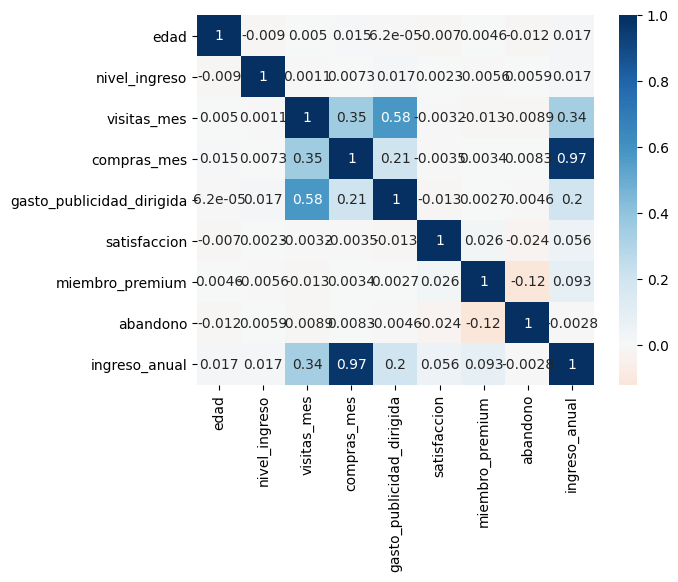

In [60]:
# Visualizar la matriz de correlación para identificar relaciones
df_corr = df[['edad','nivel_ingreso','visitas_mes','compras_mes','gasto_publicidad_dirigida','satisfaccion','miembro_premium','abandono','ingreso_anual']].corr()

sns.heatmap(df_corr, annot=True, cmap="RdBu", center=0)
plt.show()



✍️ **Comentario**:


Observaciones generales (Heatmap)  
- Diagonal principal: Presenta valores de 1.0 como es esperado, al evaluar cada variable consigo misma.
- Interacciones significativas
    - visitas_mes vs. gasto_publicidad_dirigida (0.58): Muestra una relación positiva moderada-fuerte.
    - visitas_mes vs. compras_mes (0.35): Existe una relación positiva moderada entre la frecuencia de visitas y las transacciones realizadas.
    - gasto_publicidad_dirigida vs. compras_mes (0.21): Relación positiva leve pero existente.
- Independencia de variables demográficas y de satisfacción: Variables como edad, nivel_ingreso y satisfaccion tienen correlaciones prácticamente nulas (0.00) con todas las demás variables del modelo.
- Comportamiento del abandono (Churn): Solo muestra una leve correlación negativa con miembro_premium (−0.12).


Observaciones respecto a `ingreso_anual`  
- Presenta:
    - Una relación casi lineal perfecta con compras_mes (0.97): El ingreso anual está directamente atado a la frecuencia/volumen de compras mensuales, siendo la variable predictora más fuerte de esta métrica.
    - Correlación moderada con el embudo de conversión: Guarda una relación positiva con visitas_mes (0.34) y con gasto_publicidad_dirigida (0.20).
    - Ausencia de relación con nivel_ingreso (0.017).

### Scatterplot general

### Scatterplot para pares clave

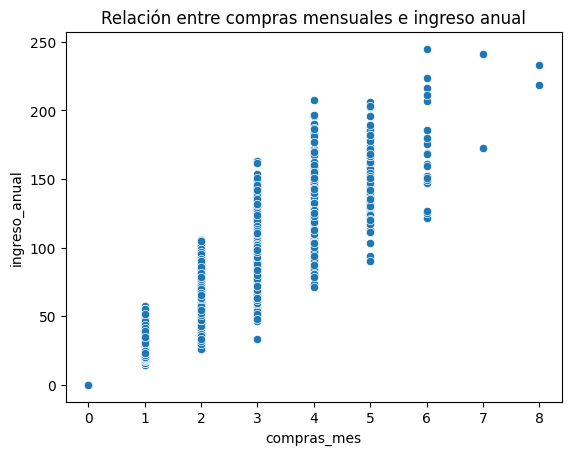

In [61]:
# Visualizar pares de variables con relaciones moderadas o fuertes
sns.scatterplot(data=df,x='compras_mes',y='ingreso_anual')
plt.title('Relación entre compras mensuales e ingreso anual')
plt.show()

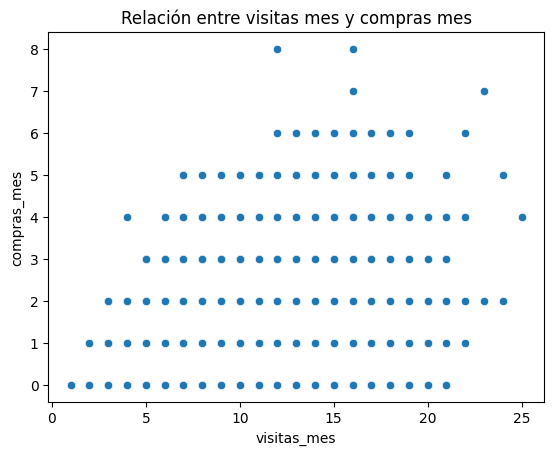

In [62]:

sns.scatterplot(data=df,x='visitas_mes',y='compras_mes')
plt.title('Relación entre visitas mes y compras mes')
plt.show()

✍️ **Comentario**:


Observaciones iniciales (Scatterplot)

**Relación entre compras mensuales e ingreso anual**
- Dirección positiva
- Dispersión (Baja a Moderada):
    La dispersión es baja, especialmente cuando se evalúa la
    tendencia general.
  
**Relación entre visitas mes y compras mes**
- Dirección positiva
- La dispersión de los datos es moderada-alta
- Presencia de Outliers (Valores atípicos)
    - Puntos aislados en compras_mes = 8 (con alrededor de 12 y
      16 visitas).
    - Un punto en compras_mes = 7 con 23 visitas.
      Están alejados de la concentración principal de los datos
      (la mayoría se agrupa entre 0 y 5 compras).

## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [63]:
# Calcular correlación entre variables relevantes
df['compras_mes'].corr(df['ingreso_anual'], method='pearson')

0.9671485435708564

In [64]:
df['compras_mes'].corr(df['ingreso_anual'], method='spearman')

0.967482492032673

In [65]:
# Calcular correlación entre variables relevantes
df['visitas_mes'].corr(df['compras_mes'], method='pearson')

0.3538438947198978

In [66]:
df['visitas_mes'].corr(df['compras_mes'], method='spearman')

0.33294292722789276

✍️ **Comentario**:

Observaciones de correlación


1. Dirección y Magnitud de las Relaciones
- compras_mes e ingreso_anual (Relación Crítica):
    - Dirección: Positiva.
    - Magnitud: Extremadamente fuerte (r=0.97). El ingreso anual crece de forma casi perfectamente lineal.
- visitas_mes con compras_mes:
    - Dirección: Positiva.
    - Magnitud: Moderada tanto con compras_mes (r=0.35) como con ingreso_anual (r=0.34).
      
2. Alerta de Colinealidad (Multicolinealidad)
- Diagnóstico de riesgo: Muy Alto entre compras_mes e ingreso_anual (r=0.97).
  

### Punto-biserial

In [67]:
# Calcular correlación entre variables relevantes
from scipy.stats import pointbiserialr

resultado = pointbiserialr(df['miembro_premium'], df['ingreso_anual'])
print(resultado)

SignificanceResult(statistic=0.0930994396198015, pvalue=3.0943076155242597e-30)


In [68]:
from scipy.stats import pointbiserialr


resultado = pointbiserialr(df['abandono'], df['ingreso_anual'])
print(resultado)


SignificanceResult(statistic=-0.002823934021617148, pvalue=0.7294691719078393)


✍️ **Comentario**:

Observaciones Punto-biserial

**Par: miembro_premium e ingreso_anual**
- Dirección: Positiva. Indica que los usuarios que son miembros premium (valor 1) tienden a generar un ingreso anual ligeramente mayor que los no premium (valor 0).
- Magnitud: Baja / Muy Leve

**Par: abandono e ingreso_anual**
- Dirección: Ligeramente Negativa. El signo negativo sugeriría que a mayor ingreso anual, menor probabilidad de abandono.
- Magnitud: Prácticamente Nula / Inexistente −0.0028).

### V de Cramér

In [69]:
# Función para calcular V de Cramér
from scipy.stats import chi2_contingency

In [70]:
def cramer_v(df, col1, col2):
    # paso 1: tabla de contingencia
    tabla = pd.crosstab(df[col1], df[col2])
    
    # paso 2: calcular chi-cuadrado
    chi2, p_value, dof, expected = chi2_contingency(tabla)

    # paso 3: calcular coeficiente V de Cramér
    n = tabla.values.sum()
    v = np.sqrt(chi2 / (n * (min(tabla.shape) -1)))
 
    return v

In [71]:
cramer_v(df,"region","tipo_dispositivo")

0.012378338407739397

✍️ **Comentario**:

Observaciones V de Cramér
- Magnitud / Fuerza de Asociación: Prácticamente Nula / Negligible. La V de Cramér toma valores en una escala fija de 0.0 a 1.0 (donde 0 es independencia total y 1 es asociación perfecta).
- Posible Colinealidad / Redundancia: Nula. Al no existir asociación entre ambas variables, no hay riesgo de redundancia.

## Sección 5 - Interpretación de resultados para el negocio

Cada hallazgo  debe incluir:
1) Evidencia visual (si aplica)
2) Evidencia numérica  
3) Interpretación (no causal)  
4) No podemos afirmar
5) Implicación de negocio
---

### Hallazgo 1 El motor transaccional del ingreso anual

**Evidencia visual:** En la matriz de correlación (heatmap), la celda que cruza la variable numérica compras_mes con ingreso_anual muestra la tonalidad de color más intensa y oscura de todo el gráfico. Asimismo, en los gráficos de dispersión (scatterplots), se aprecia una clara y estrecha alineación de puntos con una pendiente positiva pronunciada.


**Evidencia numérica:** El coeficiente de correlación de Pearson (r) entre compras_mes e ingreso_anual es de 0.97, lo que representa una asociación lineal positiva casi perfecta.


**Interpretación (no causal):** Existe una estrecha relación directa entre el número de compras mensuales que efectúa un cliente y el total de ingresos que genera al año para la empresa. Esto indica que la acumulación de transacciones repetitivas a corto plazo (mes) acompaña proporcionalmente a un valor acumulado anual sumamente alto en la facturación del usuario.


**No podemos afirmar:** Debido al enfoque estrictamente correlacional y exploratorio del proyecto, no podemos afirmar que obligar o forzar a un usuario a realizar más compras en un mes causará un aumento inmediato y predecible en su facturación anual, ya que ambas métricas podrían verse influidas por una tercera variable oculta (como el poder adquisitivo real) o reflejar simultáneamente la misma naturaleza comercial.

**Implicación de negocio:** Las estrategias de crecimiento de NovaRetail+ no deben centrarse en eventos de compra masivos pero aislados. El equipo de Crecimiento y retención debe priorizar la recurrencia periódica. Se recomienda diseñar e implementar programas de lealtad, modelos de suscripción y campañas automatizadas de reactivación enfocadas en mantener la frecuencia de compra mes a mes.



### Hallazgo 2 La disociación entre la navegación del usuario y la conversión monetaria

**Evidencia visual:** En la matriz de correlación, la intersección de visitas_mes con el ingreso_anual se representa mediante colores tenues y de baja intensidad. Visualmente, en un gráfico de dispersión, los datos muestran una nube difusa de puntos altamente dispersos que no dibujan un patrón lineal firme.

**Evidencia numérica:** La correlación de Pearson de la variable visitas_mes respecto a compras_mes es de 0.35 (r=0.3538), y de 0.33 usando spearman.


**Interpretación (no causal):** La frecuencia con la que un cliente accede o navega mensualmente en la aplicación o plataforma e-commerce guarda una relación positiva, pero de magnitud moderada a débil, con las transacciones realizadas y el ingreso anual final. Esto sugiere que acumular sesiones o clics dentro de la plataforma no se ve reflejado de forma simétrica ni equivalente en el volumen final de ingresos.


**No podemos afirmar:** No podemos afirmar que un incremento artificial del tráfico en la plataforma o un aumento en el número de visitas vaya a detonar un alza proporcional en las compras, ni tampoco que los usuarios que acumulan más visitas mensuales posean intrínsecamente una mayor intención de compra real dentro de NovaRetail+.


**Implicación de negocio:** El negocio debe desviar su enfoque de las tradicionales "métricas de vanidad" como el simple volumen de visitas o sesiones abiertas. El esfuerzo operativo debe trasladarse hacia iniciativas de Optimización de la Tasa de Conversión (CRO). Se debe optimizar la experiencia de usuario (UX) en los puntos clave del embudo de ventas, simplificar el proceso de checkout y mitigar la fricción para que el tráfico actual se traduzca de manera eficiente en compras completadas.


## Sección 6 - Limitaciones y próximos pasos

### **Limitaciones**
- Correlación ≠ causalidad:
    - Este estudio es de naturaleza explícitamente correlacional y
      exploratoria. Aunque variables como compras_mes o visitas_mes muestran
      relaciones estadísticas significativas con ingreso_anual, no es posible
      garantizar que forzar un incremento en estas métricas genere de forma
      directa o causal un mayor ingreso por usuario.
    - Sesgo de confusión no observado: Es posible que existan variables no
      incluidas en el dataset original (como satisfacción del usuario, soporte
      al cliente, categoría específica de producto comprado o promociones
      aplicadas) que estén influyendo de manera simultánea en el comportamiento
      de compra y en la retención.
    - Ventana de tiempo y representatividad: El análisis se basa en un corte
      transversal de datos correspondiente al cierre de 2024, por lo que no
      refleja comportamientos estacionales a lo largo de un ciclo anual
      completo.

### **Próximos pasos** 
1. Probar segmentación adicional
- Opción 1 (Clusterización): Implementar algoritmos de aprendizaje no supervisado (K-Means o agrupamiento jerárquico) para segmentar a los clientes en clusters basados en la combinación de compras_mes, visitas_mes y membresía premium, en lugar de analizar variables aisladas.
- Opción 2 (Análisis de regresión): Desarrollar un modelo de regresión lineal múltiple para aislar el efecto individual de visitas_mes y miembro_premium sobre ingreso_anual, ajustando y controlando los efectos cruzados entre variables.

2. Pruebas A/B para validación de causalidad
- Opción 1 (Experimentos de conversión): Diseñar una prueba A/B dirigida al segmento de usuarios con alta frecuencia de visitas (visitas_mes elevadas) pero bajo volumen de compra, evaluando el impacto de cupones de conversión o recordatorios de carrito abandonado sobre la tasa de compra real.


3. Evaluación de impacto de programa Premium y publicidad
- Opción 1 (Modelado de atribución): Analizar el retorno de inversión (ROI) de la publicidad dirigida (gasto_publicidad_dirigida) mediante un análisis de cohortes, evaluando si el incremento en inversión se traduce a largo plazo en la adquisición de clientes con mayor probabilidad de convertirse en miembros premium.